# Task 1.5: Analysis of Resource Availabilities of the BPIC-17 Eventlog

### Imports and Setup

In [52]:
import pm4py as pm
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [53]:
log = pm.read_xes("../../data/BPI Challenge 2017.xes.gz")
df_raw = pm.convert_to_dataframe(log)

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [54]:
df_whole = df_raw.copy()

Data Cleaning

In [55]:
df_whole.rename(columns={
    'org:resource': 'Resource',
    'concept:name': 'Activity',
    'time:timestamp': 'Timestamp',
    'lifecycle:transition': 'State',
    'case:concept:name': 'Case'
}, inplace=True)
df_whole.drop(columns=['EventOrigin', 'EventID', 'case:LoanGoal', 'case:ApplicationType', 'case:RequestedAmount',
       'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost',
       'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'], inplace=True)

df_whole['ResourceId'] = df_whole['Resource'].astype(str).str.lstrip('User_').astype(int)   # Used for sorting and quicker access
df_whole['Date'] = df_whole['Timestamp'].dt.date    # Needed for grouping
df_whole['Time'] = df_whole['Timestamp'].dt.time

In [56]:
# Use filtered dataframe from bpnm model for analysis
df_filtered = df_whole[~df_whole['Activity'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection', 'O_Sent (online only)'])]     # Activities not in bpmn model
df_filtered = df_filtered[df_filtered['State'].isin(['start', 'complete'])]

In [57]:
# Set df value for analysis
df = df_filtered
df = df.sort_values(['Resource', 'Timestamp'])

## Basic Approach
Daily Schedules based on median for 1-week interval

In [58]:
df.head()

,Action,Resource,Activity,State,Timestamp,Case,ResourceId,Date,Time
0,Created,User_1,A_Create Application,complete,2016-01-01 09:51:15.304000+00:00,Application_652823628,1,2016-01-01,09:51:15.304000
1,statechange,User_1,A_Submitted,complete,2016-01-01 09:51:15.352000+00:00,Application_652823628,1,2016-01-01,09:51:15.352000
5,statechange,User_1,A_Concept,complete,2016-01-01 09:52:36.413000+00:00,Application_652823628,1,2016-01-01,09:52:36.413000
40,Created,User_1,A_Create Application,complete,2016-01-01 10:16:11.500000+00:00,Application_1691306052,1,2016-01-01,10:16:11.500000
41,statechange,User_1,A_Submitted,complete,2016-01-01 10:16:11.549000+00:00,Application_1691306052,1,2016-01-01,10:16:11.549000


### Extract daily schedules

Take first start/complete timestamp and last complete timestamp

In [59]:
a_o_acts = (df.loc[df['Activity'].str.startswith(('A_', 'O_')), 'Activity'].unique().tolist())

# Define start-end conditions
valid_start_condition = ((df['State'] == 'start') 
                         | ((df['State'] == 'complete') 
                            & (df['Activity'].isin(a_o_acts))))   # A_/O_ activities only have state 'complete'
valid_end_condition = (df['State'] == 'complete')

# Extract valid start and end times
starts = (df[valid_start_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .min().rename('StartTime'))
ends = (df[valid_end_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .max().rename('EndTime'))

daily_shifts = pd.concat([starts, ends], axis=1, join='inner').reset_index()

Add relevant info needed for grouping later

In [60]:
daily_shifts['WorkedHours'] = (daily_shifts['EndTime'] - daily_shifts['StartTime']).dt.total_seconds() / 3600

# Add weekday information
daily_shifts['WeekdayName'] = pd.to_datetime(daily_shifts['Date']).dt.day_name()
daily_shifts['WeekdayId'] = pd.to_datetime(daily_shifts['Date']).dt.dayofweek

# Convert time objects to float to calculate median
daily_shifts['StartAsFloat'] = daily_shifts['StartTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)
daily_shifts['EndAsFloat'] = daily_shifts['EndTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)

print(f"Extracted {len(daily_shifts)} valid daily shifts.")

Extracted 11578 valid daily shifts.


Filter out short shifts

Created 'distribution_of_shift_durations.pdf'


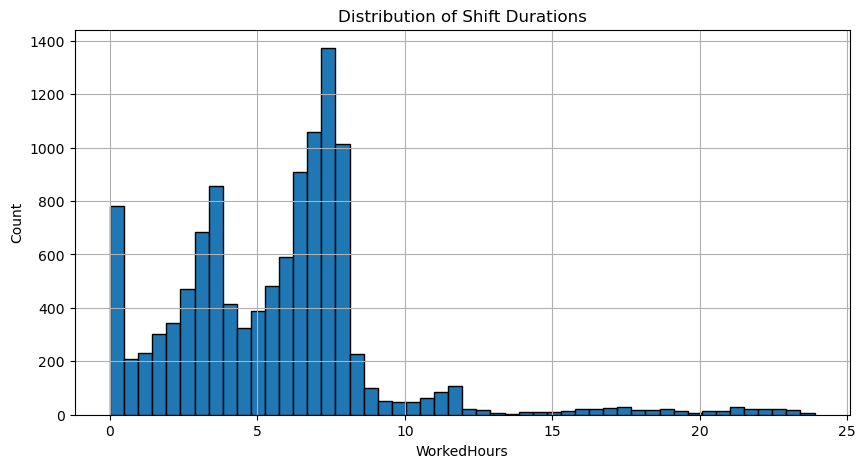

In [61]:
plt.figure(figsize=(10, 5))
daily_shifts['WorkedHours'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Shift Durations')
plt.xlabel('WorkedHours')
plt.ylabel('Count')
plt.savefig("files/distribution_of_shift_durations.pdf", format="pdf", bbox_inches="tight")
print("Created 'distribution_of_shift_durations.pdf'")

In [62]:
daily_shifts[daily_shifts['WorkedHours'] > 9].groupby('Resource')['WorkedHours'].count().sort_values(ascending=False)

Resource
User_1      365
User_75      47
User_14      26
User_3       23
User_90      18
           ... 
User_133      1
User_16       1
User_40       1
User_26       1
User_98       1
Name: WorkedHours, Length: 83, dtype: int64

In [63]:
daily_shifts[daily_shifts['WorkedHours'] < 2]['Resource'].value_counts()

Resource
User_26     52
User_2      44
User_14     36
User_10     35
User_47     35
            ..
User_59      1
User_105     1
User_104     1
User_97      1
User_132     1
Name: count, Length: 136, dtype: int64

In [64]:
min_hours = 2.0
shifts_cleaned = daily_shifts[daily_shifts['WorkedHours'] >= min_hours].copy()

print(f"Original Days: {len(daily_shifts)}")
print(f"Cleaned Days:  {len(shifts_cleaned)}")
print(f"Dropped {len(daily_shifts) - len(shifts_cleaned)} short shifts.")

Original Days: 11578
Cleaned Days:  10002
Dropped 1576 short shifts.


Created 'distribution_of_shift_durations_cleaned.pdf'


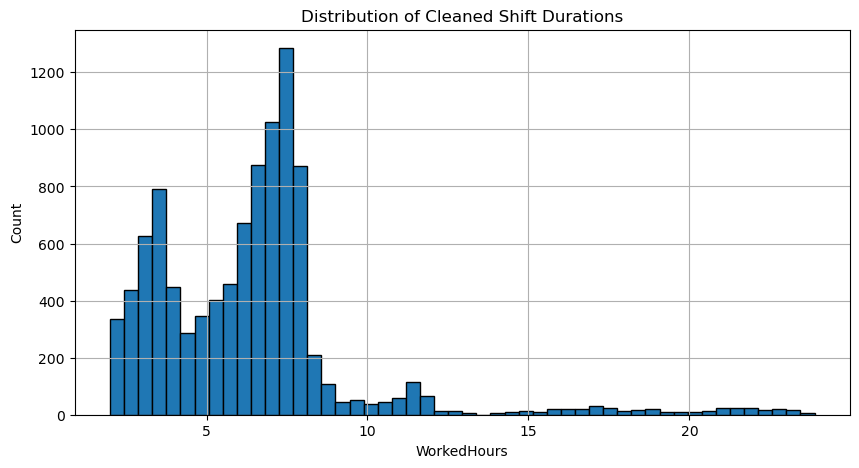

In [65]:
plt.figure(figsize=(10, 5))
shifts_cleaned['WorkedHours'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Cleaned Shift Durations')
plt.xlabel('WorkedHours')
plt.ylabel('Count')
plt.savefig("files/distribution_of_shift_durations_cleaned.pdf", format="pdf", bbox_inches="tight")
print("Created 'distribution_of_shift_durations_cleaned.pdf'")

In [66]:
shifts_cleaned.describe()

,ResourceId,WorkedHours,WeekdayId,StartAsFloat,EndAsFloat
count,10002.000000,10002.000000,10002.000000,10002.000000,10002.000000
mean,59.843731,6.442457,2.157768,8.945588,15.388045
std,39.906769,3.283124,1.575518,2.913570,2.910105
min,1.000000,2.001431,0.000000,0.009167,6.621111
25%,27.000000,4.008635,1.000000,7.235069,13.757569
50%,53.000000,6.492297,2.000000,8.167361,14.936250
75%,98.000000,7.534203,3.000000,10.034653,16.967014
max,144.000000,23.887987,6.000000,18.460278,23.996944


### Derive weekly schedule by taking the median for each week day

In [67]:
weekly_schedule = shifts_cleaned.groupby(['ResourceId', 'Resource', 'WeekdayId']).agg(
    MedianStart=('StartAsFloat', 'median'),
    MedianEnd=('EndAsFloat', 'median'),
    ShiftCount=('Date', 'count')    # How often users worked on a specific weekday
).reset_index()

Created 'shift_consistency_distribution.pdf'


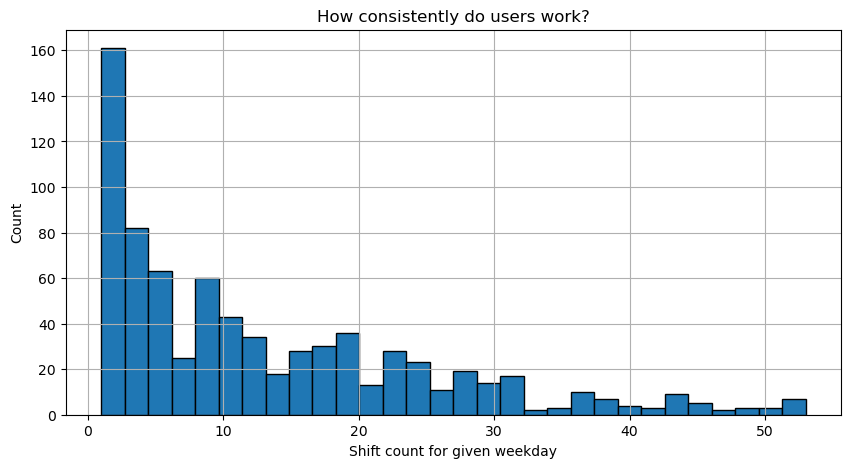

In [68]:
plt.figure(figsize=(10, 5))
weekly_schedule['ShiftCount'].hist(bins=30, edgecolor='black')
plt.title('How consistently do users work?')
plt.xlabel('Shift count for given weekday')
plt.ylabel('Count')
plt.savefig("files/shift_consistency_distribution.pdf", format="pdf", bbox_inches="tight")
print("Created 'shift_consistency_distribution.pdf'")

- most people don't work consistent hours
- some people help out once or twice on the weekends

Convert back to Time object and export as csv

In [69]:
def float_to_time(x):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return pd.to_datetime(f"{hours}:{minutes}", format="%H:%M").time()

weekly_schedule['StartTime'] = weekly_schedule['MedianStart'].apply(float_to_time)
weekly_schedule['EndTime'] = weekly_schedule['MedianEnd'].apply(float_to_time)

In [70]:
res_availvabilities = weekly_schedule[['Resource', 'WeekdayId', 'StartTime', 'EndTime']].copy()
res_availvabilities.rename(columns={'WeekdayId': 'DayId'}, inplace=True)
res_availvabilities.to_csv('availabilities_basic.csv', index=False)

Plot median weekly schedule

Created 'weekly_schedule_distribution.pdf'


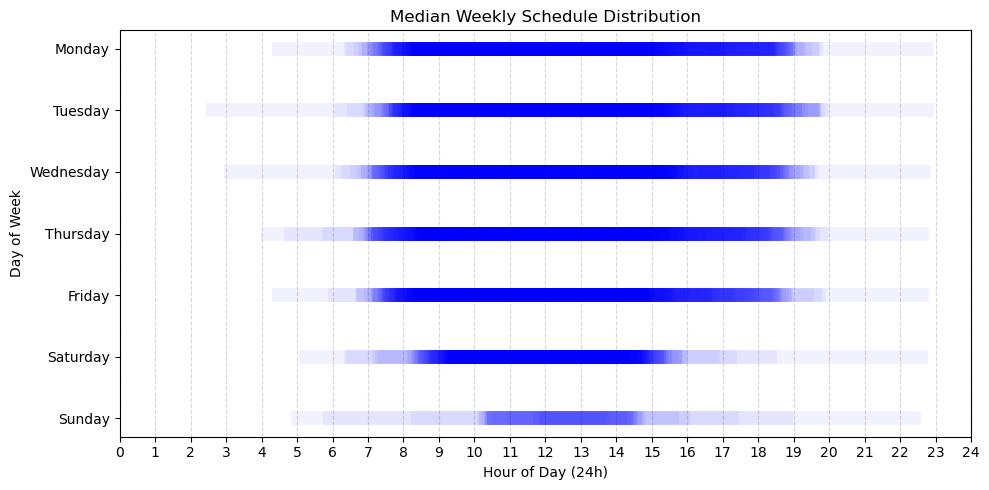

In [71]:
weekly_schedule['y_pos'] = 6 - weekly_schedule['WeekdayId']

plt.figure(figsize=(10, 5))
plt.hlines(y=weekly_schedule['y_pos'], 
           xmin=weekly_schedule['MedianStart'], 
           xmax=weekly_schedule['MedianEnd'], 
           colors='blue', 
           alpha=0.05,
           linewidth=10)
plt.yticks(range(7), ['Sunday', 'Saturday', 'Friday', 'Thursday', 'Wednesday', 'Tuesday', 'Monday'])
plt.xticks(range(25))
plt.xlim(0, 24)
plt.xlabel('Hour of Day (24h)')
plt.ylabel('Day of Week')
plt.title('Median Weekly Schedule Distribution')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('files/weekly_schedule_distribution.pdf', format="pdf", bbox_inches="tight")
print("Created 'weekly_schedule_distribution.pdf'")

## Deeper Analysis of resource availabilities for fixed intervals

#### WorkedHours

In [72]:
# Group daily durations by weekday
weekday_stats = shifts_cleaned.groupby(['Resource', 'ResourceId', 'WeekdayName', 'WeekdayId'])['WorkedHours'].agg(
    AverageHours='mean',
    MedianHours='median',
    StdDev='std',
    ShiftCount='count'
).reset_index()
weekday_stats['std/mean'] = weekday_stats['StdDev'] / weekday_stats['AverageHours']
weekday_stats = weekday_stats.sort_values(by=['ResourceId', 'WeekdayId'])

Global overview

In [73]:
global_weekday_stats = weekday_stats.groupby(['WeekdayId', 'WeekdayName'])['AverageHours'].agg(
    GlobalAverage='mean',
    GlobalMedian='median',
    GlobalStd='std',
    UserCount='count'
).reset_index().round(2)

global_weekday_stats = global_weekday_stats.sort_values('WeekdayId')
global_weekday_stats

,WeekdayId,WeekdayName,GlobalAverage,GlobalMedian,GlobalStd,UserCount
0,0,Monday,5.97,6.01,1.62,132
1,1,Tuesday,5.93,6.10,1.80,129
2,2,Wednesday,5.97,6.07,1.79,131
3,3,Thursday,5.84,5.70,1.83,132
4,4,Friday,5.55,5.57,1.68,131
5,5,Saturday,5.34,5.51,1.90,88
6,6,Sunday,5.63,4.35,3.70,20


In [74]:
def get_metric_overview(metric):
    pivot_overview = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values=metric).fillna(0)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_overview = pivot_overview.reindex(columns=days_order).sort_index()
    return pivot_overview.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.1f}")

def color_thresholds(val):
    if val < 0.3:
        color ='#90EE90'
    elif val < 0.5:
        color = '#FFFFE0'
    else:
        color = '#FF7F7F'
    return f'background-color: {color}'

Average

In [75]:
avg_hours_overview = get_metric_overview('AverageHours')
avg_hours_overview.to_html("files/avg_hours.html")
print("Created 'avg_hours.html'")

Created 'avg_hours.html'


- User_1 consistent high activity => most likely system
- work hours around 4-6 hours
- some work consistently on Saturdays

Median

In [76]:
median_hours_overview = get_metric_overview('MedianHours')
median_hours_overview.to_html("files/median_hours.html")
print("Created 'median_hours.html'")

Created 'median_hours.html'


Relative Standard Deviation

In [77]:
std_hours_overview = get_metric_overview('StdDev')
std_hours_overview.to_html("files/std_hours.html")
print("Created 'std_hours.html'")

Created 'std_hours.html'


In [78]:
# Get better overview over relative standard deviation
pivot_relstd = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values='std/mean').fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_relstd = pivot_relstd.reindex(columns=days_order).sort_index()
relstd_overview = pivot_relstd.style.map(color_thresholds).format("{:.1f}")
relstd_overview.to_html("files/relative_standard_deviation.html")
print("Created 'relative_standard_deviation.html'")

Created 'relative_standard_deviation.html'


#### Inspect resource shifts for single users

Created 'shift_schedule_timeline_User_100.pdf'


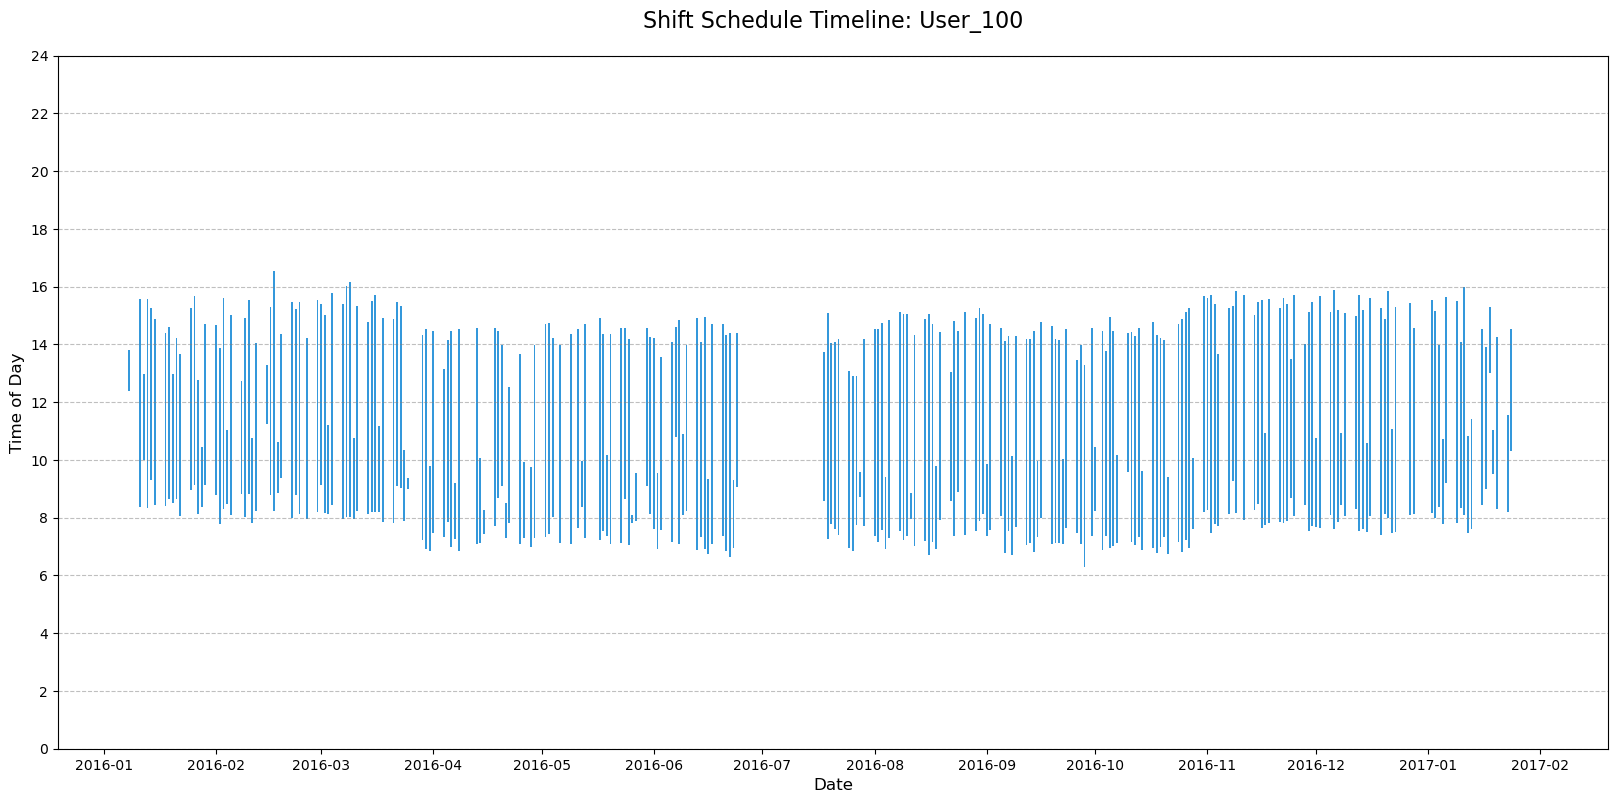

In [79]:
res_id = 'User_100'
tmp = daily_shifts[daily_shifts['Resource'] == res_id].copy()

fig, ax = plt.subplots(figsize=(20, 9))
ax.bar(
    mdates.date2num(tmp['Date']),
    tmp['WorkedHours'],
    bottom=tmp['StartTime'].apply(lambda x: x.hour + x.minute / 60),
    width=0.5,
    color='#3498db',
    edgecolor='none',
    align='center'
)
locator = mdates.MonthLocator(interval=1)
ax.xaxis.set_major_locator(locator)

formatter = mdates.DateFormatter('%Y-%m')
ax.xaxis.set_major_formatter(formatter)

ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_ylabel("Time of Day", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

ax.set_title(f"Shift Schedule Timeline: {res_id}", fontsize=16, pad=20)
ax.set_xlabel("Date", fontsize=12)
plt.savefig(f"files/shift_schedule_timeline_{res_id}.pdf", format="pdf", bbox_inches="tight")
print(f"Created 'shift_schedule_timeline_{res_id}.pdf'")

## Advanced Approach

#### Holidays

Find lower volume days based on daily shifts

In [80]:
daily_volume = daily_shifts.groupby(['Date', 'WeekdayId'])['WorkedHours'].sum().reset_index()

weekdays_only = daily_volume[daily_volume['WeekdayId'] < 5]
baseline_volume = weekdays_only['WorkedHours'].mean()
print(f"Standard Daily Volume: {baseline_volume:.1f} hours")

threshold = 0.3
is_holiday = ((daily_volume['WeekdayId'] < 5) & 
        (daily_volume['WorkedHours'] < (baseline_volume * threshold)))
    
holidays = daily_volume[is_holiday].copy()
holidays['Ratio'] = holidays['WorkedHours'] / baseline_volume
holidays = holidays.sort_values('Date')
print(f"\nDetected {len(holidays)} Holidays:")
print(holidays)

Standard Daily Volume: 212.7 hours

Detected 15 Holidays:
           Date  WeekdayId  WorkedHours     Ratio
0    2016-01-01          4    12.127297  0.057023
117  2016-04-27          2    42.222226  0.198532
125  2016-05-05          3    53.229695  0.250290
136  2016-05-16          0    56.043163  0.263519
360  2016-12-26          0    49.110984  0.230924
382  2017-01-17          1    63.046886  0.296451
384  2017-01-19          3    52.675935  0.247686
385  2017-01-20          4    62.544444  0.294089
389  2017-01-24          1    38.352314  0.180335
390  2017-01-25          2    13.056986  0.061395
391  2017-01-26          3    18.981491  0.089252
392  2017-01-27          4    32.342614  0.152077
395  2017-01-30          0    13.032585  0.061280
396  2017-01-31          1    21.480533  0.101003
397  2017-02-01          2     2.406667  0.011316


from https://www.government.nl/topics/working-hours/question-and-answer/public-holidays-in-the-netherlands:
- New Year's: 01 January
- King's Day: 27 April
- Liberation Day: 5 May
- Ascension Day: different every year
- Christmas Day: 25 December
- Boxing Day: 26 December

In [81]:
holidays['Date'] = pd.to_datetime(holidays['Date'])
holidays_filtered = holidays[holidays['Date'].dt.year < 2017].copy()

In [82]:
daily_shifts['Date'] = pd.to_datetime(daily_shifts['Date'])
active_on_holiday = daily_shifts[
        (daily_shifts['Date'].isin(holidays_filtered['Date'].tolist())) & 
        (daily_shifts['WorkedHours'] > 0.01)
    ]
    
print("Users working on holidays:")
if active_on_holiday.empty:
    print("No one!")
else:
    workers_per_day = active_on_holiday.groupby('Date')['Resource'].unique()
    for date_val, workers in workers_per_day.items():
        worker_list = ", ".join(workers)
        print(f"   - {date_val}: {len(workers)} active ({worker_list})")

Users working on holidays:
   - 2016-01-01 00:00:00: 1 active (User_1)
   - 2016-04-27 00:00:00: 9 active (User_1, User_3, User_18, User_35, User_36, User_42, User_44, User_75, User_117)
   - 2016-05-05 00:00:00: 11 active (User_1, User_3, User_12, User_13, User_14, User_26, User_31, User_38, User_43, User_49, User_116)
   - 2016-05-16 00:00:00: 12 active (User_1, User_4, User_13, User_15, User_16, User_24, User_28, User_36, User_42, User_49, User_60, User_125)
   - 2016-12-26 00:00:00: 8 active (User_1, User_39, User_42, User_51, User_52, User_61, User_66, User_113)


#### Lunch Break

In [83]:
df_adv = df_filtered[df_filtered['Resource'] != 'User_1'].copy()  # User_1 is system with no lunch break

Plot timestamps with status 'start' or 'complete' for a specific user

Created 'break_time_analysis_User_100.pdf'


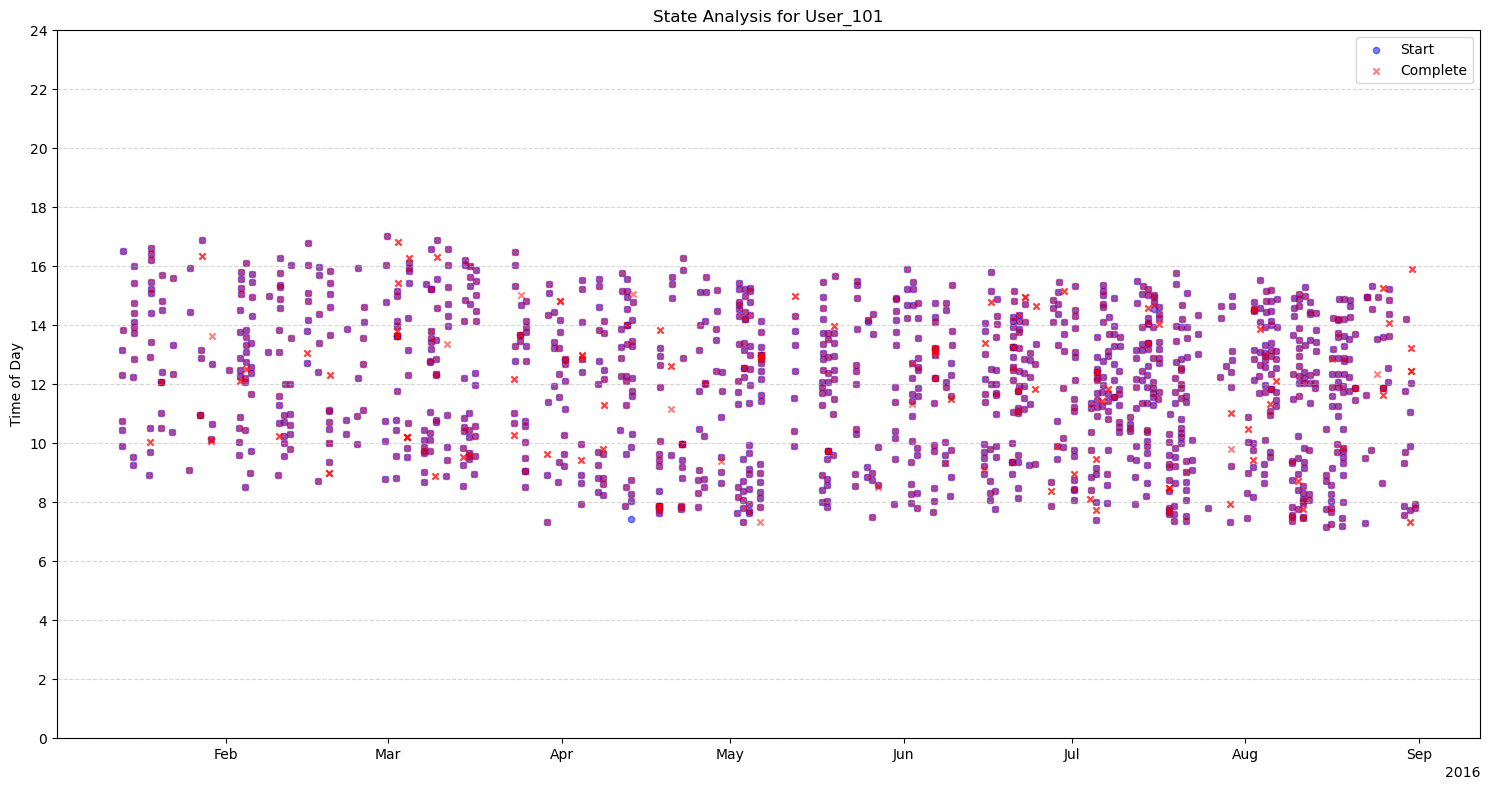

In [84]:
user_id = 'User_101'  # Change to inspect different users
user_df = df_adv[df_adv['Resource'] == user_id].copy()
user_df['TimeFloat'] = (
        user_df['Timestamp'].dt.hour + 
        user_df['Timestamp'].dt.minute / 60 + 
        user_df['Timestamp'].dt.second / 3600
    )
starts = user_df[user_df['State'] == 'start']
completes = user_df[user_df['State'] == 'complete']

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(starts['Timestamp'], starts['TimeFloat'], color='blue', alpha=0.5, s=20, label='Start')
ax.scatter(completes['Timestamp'], completes['TimeFloat'], color='red', marker='x', alpha=0.5, s=20, label='Complete')
ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_ylabel('Time of Day')

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.title(f'State Analysis for {user_id}')
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f"files/break_time_analysis_{res_id}.pdf", format="pdf", bbox_inches="tight")
print(f"Created 'break_time_analysis_{res_id}.pdf'")

Extract longest period between complete/complete or complete/start timestamps to get breaks

In [85]:
df_adv = df_adv.sort_values(['Resource', 'Timestamp']).copy()

df_adv['NextTimestamp'] = df_adv.groupby('Resource')['Timestamp'].shift(-1)
df_adv['Gap'] = df_adv['NextTimestamp'] - df_adv['Timestamp']

valid_breaks = ((df_adv['State'] == 'complete') & 
        (df_adv['Timestamp'].dt.date == df_adv['NextTimestamp'].dt.date))   # gaps between State 'start' and 'complete' defined as 'working' not break'
    
potential_breaks = df_adv[valid_breaks].copy()

idx_longest = potential_breaks.groupby(['Resource', potential_breaks['Timestamp'].dt.date])['Gap'].idxmax()     # Longest break
breaks = potential_breaks.loc[idx_longest]
breaks = pd.DataFrame({
    'Resource': breaks['Resource'],
    'Date': breaks['Timestamp'].dt.date,
    'BreakStart': breaks['Timestamp'],
    'BreakEnd': breaks['NextTimestamp'],
    'Duration': breaks['Gap']
    })
breaks['DurationHours'] = breaks['Duration'].dt.total_seconds() / 3600

Plot break durations

Created 'lunch_break_duration.pdf'


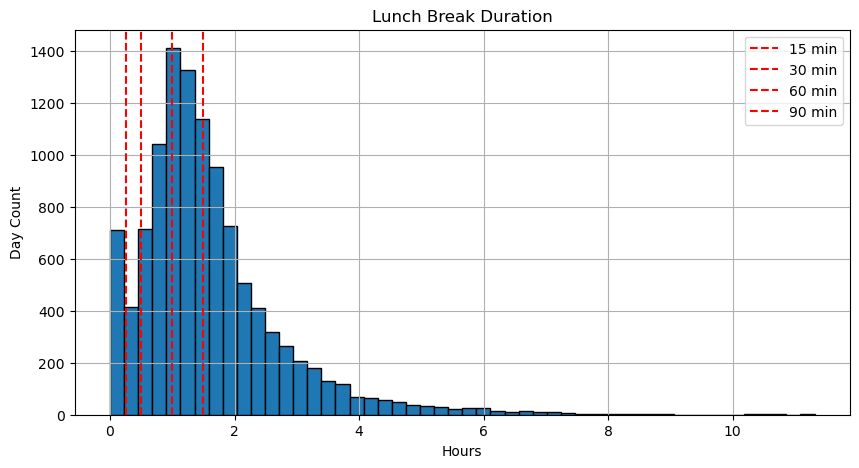

In [86]:
plt.figure(figsize=(10, 5))
breaks['DurationHours'].hist(bins=50, edgecolor='black')
plt.title('Lunch Break Duration')
plt.xlabel('Hours')
plt.ylabel('Day Count')
plt.axvline(x=0.25, color='r', linestyle='--', label='15 min')
plt.axvline(x=0.5, color='r', linestyle='--', label='30 min')
plt.axvline(x=1.0, color='r', linestyle='--', label='60 min')
plt.axvline(x=1.5, color='r', linestyle='--', label='90 min')
plt.legend()
plt.savefig(f"files/lunch_break_duration.pdf", format="pdf", bbox_inches="tight")
print(f"Created 'lunch_break_duration.pdf'")

Filter out outliers

In [87]:
breaks.describe()

,Duration,DurationHours
count,11075,1.107500e+04
mean,0 days 01:34:57.314963611,1.582587e+00
std,0 days 01:09:15.746311286,1.154374e+00
min,0 days 00:00:00.002000,5.555556e-07
25%,0 days 00:53:14.593000,8.873869e-01
50%,0 days 01:20:36.003000,1.343334e+00
75%,0 days 01:59:02.590500,1.984053e+00
max,0 days 11:18:50.768000,1.131410e+01


In [88]:
min_hours = 15 / 60     # 15 min
max_hours = 3
breaks_cleaned = breaks[(breaks['DurationHours'] >= min_hours)
                        & (breaks['DurationHours'] <= max_hours)].copy()

print(f"Original Lunch Breaks: {len(breaks)}")
print(f"Cleaned Lunch Breaks:  {len(breaks_cleaned)}")
print(f"Dropped {len(breaks) - len(breaks_cleaned)} outliers.")

Original Lunch Breaks: 11075
Cleaned Lunch Breaks:  9243
Dropped 1832 outliers.


Created 'lunch_break_duration_cleaned.pdf'


/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_28999/1953370256.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


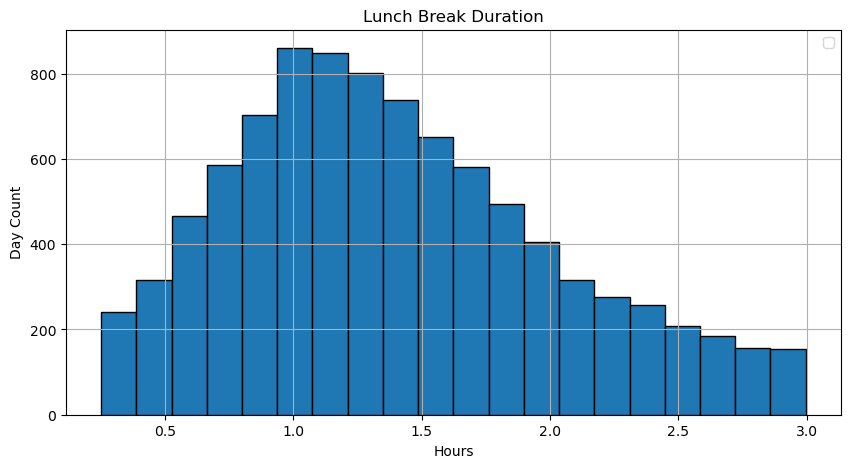

In [89]:
plt.figure(figsize=(10, 5))
breaks_cleaned['DurationHours'].hist(bins=20, edgecolor='black')
plt.title('Lunch Break Duration')
plt.xlabel('Hours')
plt.ylabel('Day Count')
plt.legend()
plt.savefig(f"files/lunch_break_duration_cleaned.pdf", format="pdf", bbox_inches="tight")
print(f"Created 'lunch_break_duration_cleaned.pdf'")

In [90]:
breaks_cleaned.describe()

,Duration,DurationHours
count,9243,9243.000000
mean,0 days 01:23:58.627384182,1.399619
std,0 days 00:37:32.468816343,0.625686
min,0 days 00:15:02.674000,0.250743
25%,0 days 00:56:16.090500,0.937803
50%,0 days 01:18:51.797000,1.314388
75%,0 days 01:48:03.193000,1.800887
max,0 days 02:59:46.571000,2.996270


#### Calculate median of all lunch break durations and start times (all data)

In [91]:
breaks_cleaned['BreakStartFloat'] = (
    breaks_cleaned['BreakStart'].dt.hour + 
    breaks_cleaned['BreakStart'].dt.minute / 60
)

breaks_cleaned_dof = breaks_cleaned.copy()
breaks_cleaned_dof['DayId'] = breaks_cleaned_dof['BreakStart'].dt.dayofweek

In [92]:
# Total average over all days
breaks_median = breaks_cleaned.groupby('Resource').agg(
    DurationMedian=('DurationHours', 'median'),
    BreakStartMedian=('BreakStartFloat', 'median')
).reset_index()
breaks_median['BreakStart'] = breaks_median['BreakStartMedian'].apply(float_to_time)
breaks_median['DurationMin'] = (breaks_median['DurationMedian'] * 60).round(0).astype(int)     # Convert to minutes

In [93]:
breaks_median.describe()

,DurationMedian,BreakStartMedian,DurationMin
count,141.000000,141.000000,141.000000
mean,1.270197,11.783629,76.226950
std,0.300494,1.712958,18.033845
min,0.432514,4.383333,26.000000
25%,1.112264,10.700000,67.000000
50%,1.277718,11.450000,77.000000
75%,1.446507,12.641667,87.000000
max,2.449339,16.950000,147.000000


Plot start times

Created 'distributions_lunch_start_times.pdf'


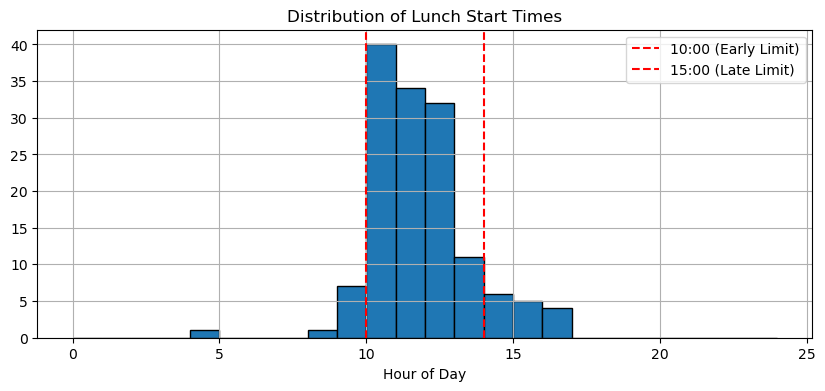

In [94]:
plt.figure(figsize=(10, 4))
breaks_median['BreakStartMedian'].hist(bins=24, range=(0, 24), edgecolor='black')
plt.title('Distribution of Lunch Start Times')
plt.xlabel('Hour of Day')
plt.axvline(x=10, color='red', linestyle='--', label='10:00 (Early Limit)')
plt.axvline(x=14, color='red', linestyle='--', label='15:00 (Late Limit)')
plt.legend()
plt.savefig(f"files/distributions_lunch_start_times.pdf", format="pdf", bbox_inches="tight")
print(f"Created 'distributions_lunch_start_times.pdf'")

#### Median start times and durations grouped by weekdays

In [95]:
# Get median for weekdays
breaks_median_dof = breaks_cleaned_dof.groupby(['Resource', 'DayId']).agg(
    DurationMedian=('DurationHours', 'median'),
    BreakStartMedian=('BreakStartFloat', 'median')
).reset_index()
breaks_median_dof['BreakStart'] = breaks_median_dof['BreakStartMedian'].apply(float_to_time)
breaks_median_dof['DurationMin'] = (breaks_median_dof['DurationMedian'] * 60).round(0).astype(int)     # Convert to minutes

Save results to csv

In [96]:
res_lunch_break = breaks_median_dof[[
        'Resource', 
        'BreakStart',
        'DurationMin',
        'DayId'
    ]]

In [97]:
res_availvabilities_adv = pd.merge(res_availvabilities, res_lunch_break, how='left')
res_availvabilities_adv['DurationMin'] = res_availvabilities_adv['DurationMin'].fillna(0)
res_availvabilities_adv['BreakStart'] = res_availvabilities_adv['BreakStart'].fillna("00:00:00")

### Evaluation of start, break and endtimes

In [98]:
def to_td(col):
    return pd.to_timedelta(col)

has_break = res_availvabilities_adv['DurationMin'] > 0
break_too_early = (to_td(res_availvabilities_adv['BreakStart'].astype(str)) < to_td(res_availvabilities_adv['StartTime'].astype(str))) & has_break
break_too_late = ((to_td(res_availvabilities_adv['BreakStart'].astype(str)) + pd.to_timedelta(res_availvabilities_adv['DurationMin'], unit='m')) > to_td(res_availvabilities_adv['EndTime'].astype(str))) & has_break

print(f"Total Shifts: {len(df)}")
print(f"Errors Found: {break_too_early.sum()} starts too early, {break_too_late.sum()} ends too late.")
print("\n--- Rows with Break Issues ---")
print(res_availvabilities_adv[(break_too_early | break_too_late)][['Resource', 'DayId', 'StartTime', 'EndTime', 'BreakStart', 'DurationMin']])

Total Shifts: 600790
Errors Found: 11 starts too early, 20 ends too late.

--- Rows with Break Issues ---
     Resource  DayId StartTime   EndTime BreakStart  DurationMin
47     User_9      2  14:30:00  17:51:00   14:22:00        106.0
73    User_13      3  10:56:00  18:16:00   17:10:00         74.0
115   User_20      3  11:16:00  14:42:00   13:46:00         76.0
140   User_24      4  12:21:00  15:12:00   15:11:00         66.0
198   User_34      3  14:29:00  19:10:00   17:32:00        105.0
203   User_35      3  08:35:00  15:54:00   15:33:00        105.0
227   User_39      1  11:50:00  15:29:00   14:24:00         67.0
321   User_54      2  11:20:00  18:32:00   10:53:00        106.0
372   User_63      4  08:47:00  12:13:00   10:35:00        107.0
374   User_64      0  09:52:00  13:30:00   12:28:00         88.0
375   User_64      4  11:09:00  16:39:00   09:58:00        129.0
376   User_64      5  10:00:00  13:35:00   13:07:00         55.0
399   User_68      5  06:23:00  08:26:00   06:00:

In [99]:
# Set early breaks to 0
res_availvabilities_adv.loc[break_too_early, 'DurationMin'] = 0
res_availvabilities_adv.loc[break_too_early, 'BreakStart'] = "00:00:00"

# Set late breaks to end of shift
res_availvabilities_adv.loc[break_too_late, 'DurationMin'] = 0
remaining_time = to_td(res_availvabilities_adv['EndTime'].astype(str)) - to_td(res_availvabilities_adv['BreakStart'].astype(str))
remaining_minutes = remaining_time.dt.total_seconds() / 60
res_availvabilities_adv.loc[break_too_late, 'DurationMin'] = remaining_minutes[break_too_late].clip(lower=0).astype(int)


In [100]:
res_availvabilities_adv.to_csv('availabilities_advanced.csv', index=False)
print("Created 'availabilities_advanced.csv'")

Created 'availabilities_advanced.csv'
